# 課題3 Segmentation: FCN / SAM 3

この課題では、セマンティックセグメンテーションを扱います。

COCO から2枚の画像を選びます。1枚目は `person` が写っている画像、2枚目は `bus`  が写っている画像です。各画像に対して、torchvision の pretrained FCN-ResNet50 と、ローカルに配置した SAM 3 checkpoint を使って segmentation を試します。

## Segmentation の考え方

Segmentation network は AutoEncoder と同じように Encoder-Decoder 型の構造を持ちます。ただし AutoEncoder の出力は復元画像ですが、Semantic Segmentation の出力はカテゴリ数分のチャネルを持つ segmentation mask です。各ピクセルについてカテゴリスコアを出し、通常は pixel ごとに softmax を考えます。

この notebook では、FCN の pretrained model を使って実際の segmentation map を出力します。また、SAM 3 では text prompt を使って対象物の segmentation を行います。

In [1]:
from pathlib import Path
import json
import os
import math
import random
import numpy as np
import torch
from torchvision import models
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# JupyterHub上での課題フォルダ。推論結果画像は課題3のout/に保存する。
BASE_DIR = Path('/export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2')
TASK_DIR = BASE_DIR / 'kadai3-segmentation_detection_sam3'
OUT_DIR = TASK_DIR / 'out'
MODEL_DIR = TASK_DIR / 'model'

# 学校・研究室で共有されているCOCO画像とannotationを使う。
COCO_DIR = Path('/export/data/dataset/COCO')
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# 今回の規模ではGPU 1枚で十分なので、GPU:0だけを使う。
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('COCO exists:', COCO_DIR.exists())
print('model dir:', MODEL_DIR)

device: cuda
COCO exists: True
model dir: /export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2/kadai3-segmentation_detection_sam3/model


## COCO から person 画像と bus/airplane 画像を選ぶ

COCO annotation が使える場合、カテゴリ名から画像を探します。`person` が写っている画像を1枚、`bus`  が写っている画像を1枚選びます。annotation が見つからない場合は、COCO の画像ファイルから fallback で2枚選びます。

In [25]:
def find_annotation_file(coco_dir):
    candidates = [
        coco_dir / 'annotations' / 'instances_train2014.json',
        coco_dir / 'annotations' / 'instances_val2014.json',
        coco_dir / 'annotations.org' / 'instances_train2014.json',
        coco_dir / 'annotations.org' / 'instances_val2014.json',
    ]
    for path in candidates:
        if path.exists():
            return path
    return None

def image_path_from_file_name(coco_dir, file_name):
    for split in ['val2014', 'train2014', 'test2014']:
        path = coco_dir / split / file_name
        if path.exists():
            return path
    matches = list(coco_dir.glob(f'**/{file_name}'))
    if matches:
        return matches[0]
    raise FileNotFoundError(file_name)

def select_coco_images_by_category(coco_dir):
    ann_path = find_annotation_file(coco_dir)
    selected = []
    if ann_path is not None:
        print('annotation:', ann_path)
        data = json.loads(ann_path.read_text())
        cat_name_to_id = {c['name']: c['id'] for c in data['categories']}
        image_id_to_file = {img['id']: img['file_name'] for img in data['images']}

        def pick(label, category_names):
            cat_ids = {cat_name_to_id[name] for name in category_names if name in cat_name_to_id}
            for ann in data['annotations']:
                if ann['category_id'] in cat_ids and ann.get('area', 10) > 10000:
                    file_name = image_id_to_file[ann['image_id']]
                    return {'label': label, 'prompt': list(category_names), 'path': image_path_from_file_name(coco_dir, file_name)}
            return None

        selected.append(pick('person_image', ['person']))
        selected.append(pick('vehicle_image', ['bus']))
        selected = [s for s in selected if s is not None]

    if len(selected) < 2:
        print('annotation based selection failed. fallback to image files.')
        paths = []
        for split in ['val2014', 'train2014']:
            root = coco_dir / split
            if root.exists():
                paths.extend(sorted(root.glob('*.jpg')))
        if len(paths) < 2:
            raise FileNotFoundError(f'COCO images were not found under {coco_dir}')
        selected = [
            {'label': 'person_image_fallback', 'prompt': ['person'], 'path': paths[1000]},
            {'label': 'vehicle_image_fallback', 'prompt': ['bus'], 'path': paths[10000]},
        ]
    return selected[:2]

selected_images = select_coco_images_by_category(COCO_DIR)
for item in selected_images:
    print(item['label'], item['prompt'], item['path'])

annotation: /export/data/dataset/COCO/annotations/instances_train2014.json
person_image ['person'] /export/data/dataset/COCO/train2014/COCO_train2014_000000044474.jpg
vehicle_image ['bus'] /export/data/dataset/COCO/train2014/COCO_train2014_000000415455.jpg


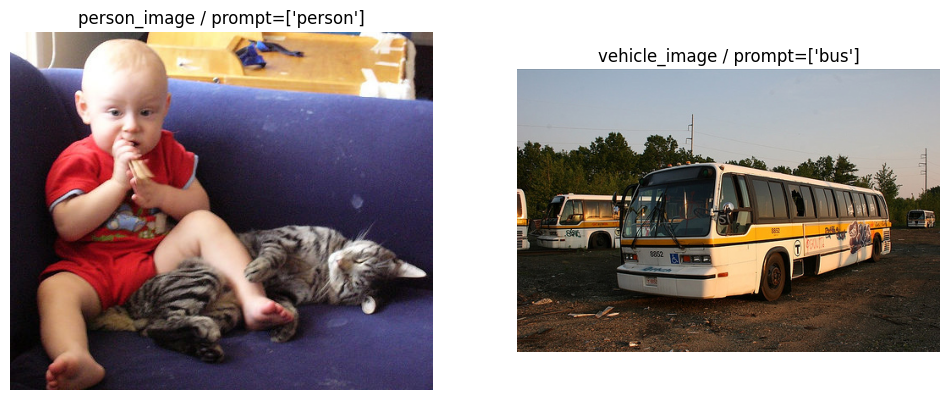

In [27]:
images = []
for item in selected_images:
    img = Image.open(item['path']).convert('RGB')
    images.append({**item, 'image': img})

plt.figure(figsize=(12, 5))
for i, item in enumerate(images):
    plt.subplot(1, 2, i + 1)
    plt.imshow(item['image'])
    plt.axis('off')
    plt.title(f"{item['label']} / prompt={item['prompt']}")
plt.savefig(OUT_DIR / 'selected_coco_images.png', dpi=160, bbox_inches='tight')
plt.show()

## FCN-ResNet50 による semantic segmentation

FCN は Fully Convolutional Network の略で、全結合層ではなく畳み込みだけで pixel-wise な出力を作る segmentation model です。ここでは torchvision の pretrained FCN-ResNet50 を使い、2枚の COCO 画像に対して segmentation map を出します。

In [28]:
# pretrained FCNを使い、各ピクセルのカテゴリを推定する。
seg_weights = models.segmentation.FCN_ResNet50_Weights.DEFAULT
seg_model = models.segmentation.fcn_resnet50(weights=seg_weights).to(device).eval()

fcn_results = []
for item in images:
    # pretrained weightに対応した前処理を使う。
    x = seg_weights.transforms()(item['image']).unsqueeze(0).to(device)
    with torch.no_grad():
        # outのshapeは [1, クラス数, H, W]。各ピクセルで最大スコアのクラスを選ぶ。
        output = seg_model(x)['out']
        label_map = output[0].argmax(0).cpu().numpy()
    fcn_results.append({**item, 'label_map': label_map, 'output_shape': tuple(output.shape)})
    print(item['label'], 'output shape:', tuple(output.shape), 'label map:', label_map.shape, 'labels:', np.unique(label_map)[:20])

person_image output shape: (1, 21, 520, 613) label map: (520, 613) labels: [ 0  8  9 15 18]
vehicle_image output shape: (1, 21, 520, 776) label map: (520, 776) labels: [0 6]


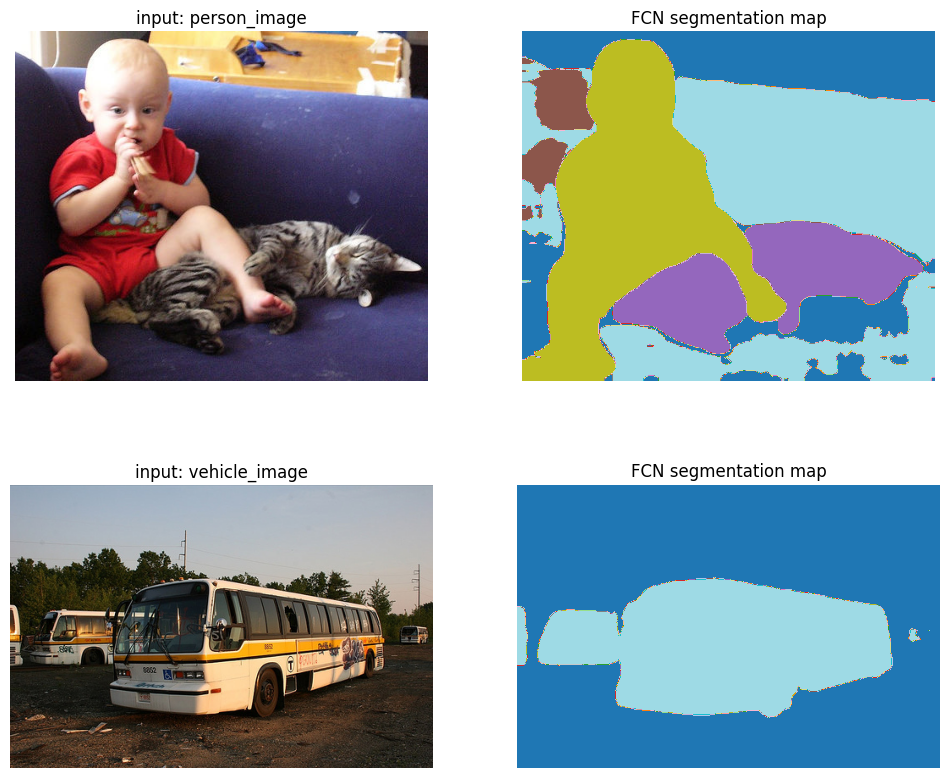

In [29]:
# 2枚の元画像とFCN segmentation mapを並べて保存する。
plt.figure(figsize=(12, 10))
for i, item in enumerate(fcn_results):
    plt.subplot(2, 2, 2 * i + 1)
    plt.imshow(item['image'])
    plt.axis('off')
    plt.title(f"input: {item['label']}")

    plt.subplot(2, 2, 2 * i + 2)
    plt.imshow(item['label_map'], cmap='tab20')
    plt.axis('off')
    plt.title('FCN segmentation map')

plt.savefig(OUT_DIR / 'segmentation_fcn_two_coco_images.png', dpi=160, bbox_inches='tight')
plt.show()

## SAM 3 のローカル実行

SAM 3 は手動で checkpoint をダウンロードし、`kadai3-segmentation_detection_sam3/model/sam3.pt` に置いてから実行します。すでに動作確認できた場合は、`RUN_SAM3=True` にしてこのセルを実行します。

SAM 3 では、1枚目に `person`、2枚目に `bus` / `airplane` の text prompt を与えます。

In [34]:
# SAM 3はcheckpointと依存関係の準備が必要なため、準備できた時だけTrueにする。
RUN_SAM3 = True
if RUN_SAM3:
    from ultralytics.models.sam import SAM3SemanticPredictor
    sam3_ckpt = MODEL_DIR / 'sam3.pt'
    if not sam3_ckpt.exists():
        raise FileNotFoundError(f'SAM 3 checkpoint not found: {sam3_ckpt}')

    overrides = dict(
        conf=0.25,
        task='segment',
        mode='predict',
        model=str(sam3_ckpt),
        half=torch.cuda.is_available(),
        save=False,          # 個別保存しない
        project=str(OUT_DIR),
        name='sam3_predict',
        exist_ok=True,
    )
    predictor = SAM3SemanticPredictor(overrides=overrides)
    sam3_results = []

    for item in images:
        # ── 一時ファイルなしで直接渡せる場合はそちらを優先 ──
        result = predictor(source=item['image'], text=item['prompt'])
        sam3_results.append({
            'label':  item['label'],
            'prompt': item['prompt'],
            'input':  item['image'],   # PIL Image
            'result': result,
        })
        print(item['label'], 'prompt=', item['prompt'], result)

    # ── グリッド画像にまとめて保存 ──────────────────────────────────
    THUMB_W, THUMB_H = 512, 512
    PADDING = 8
    HEADER_H = 28  # ラベル用テキスト行の高さ

    def result_to_pil(result) -> Image.Image:
        """ultralytics の Result オブジェクトから PIL Image を取得する。"""
        # plot() は BGR numpy array を返す
        arr = result[0].plot() if isinstance(result, list) else result.plot()
        return Image.fromarray(arr[..., ::-1])  # BGR→RGB

    pairs = []
    for r in sam3_results:
        inp_img = r['input'].convert('RGB').resize((THUMB_W, THUMB_H))
        out_img = result_to_pil(r['result']).resize((THUMB_W, THUMB_H))
        pairs.append((r['label'], r['prompt'], inp_img, out_img))

    n      = len(pairs)
    cols   = 2          # 1列 = (input, output) の2枚
    rows   = n          # サンプル数分の行
    cell_w = THUMB_W
    cell_h = THUMB_H + HEADER_H

    grid_w = cols * cell_w + (cols + 1) * PADDING
    grid_h = rows * cell_h + (rows + 1) * PADDING

    grid = Image.new('RGB', (grid_w, grid_h), color=(30, 30, 30))
    draw = ImageDraw.Draw(grid)
    try:
        font = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', 14)
    except OSError:
        font = ImageFont.load_default()

    for row_idx, (label, prompt, inp_img, out_img) in enumerate(pairs):
        y_base = PADDING + row_idx * (cell_h + PADDING)
        for col_idx, (img, tag) in enumerate([(inp_img, 'INPUT'), (out_img, 'OUTPUT')]):
            x = PADDING + col_idx * (cell_w + PADDING)
            # ラベルテキスト
            text = f'[{tag}] {label}' + (f'  "{prompt}"' if col_idx == 1 else '')
            draw.text((x + 4, y_base + 4), text, fill=(220, 220, 100), font=font)
            # サムネイル貼り付け
            grid.paste(img, (x, y_base + HEADER_H))

    save_path = OUT_DIR / 'sam3_summary.png'
    grid.save(save_path)
    print(f'サマリー画像を保存しました: {save_path}')

else:
    print('SAM 3はcheckpointと依存関係を準備してから RUN_SAM3=True にしてください。')


Ultralytics 8.4.56 🚀 Python-3.8.13 torch-2.4.1+cu121 CUDA:0 (NVIDIA TITAN RTX, 24023MiB)
WARNING ⚠️ imgsz=[640] must be multiple of max stride 14, updating to [644]
0: 644x644 1 person, 83.6ms
Speed: 5.3ms preprocess, 83.6ms inference, 0.7ms postprocess per image at shape (1, 3, 644, 644)
person_image prompt= ['person'] [ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: ['person']
obb: None
orig_img: array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 69,  83, 105],
        [ 68,  83, 102],
        [ 67,  82, 101]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 76,  90, 112],
        [ 76,  91, 110],
        [ 75,  90, 109]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 79,  92, 114],
        [ 78,  92, 111],
